# Propensity Score Matching — NHEFS

Estimates the average treatment effect on the treated (ATT) of **quitting smoking** on **weight change** using NHEFS data (Hernán & Robins, *Causal Inference: What If?*).

| | |
|---|---|
| **Treatment** | `quit_smoking` — quit smoking between 1971 and 1982 |
| **Outcome** | `weight_change_kg` — weight change in kg (1982 − 1971) |
| **Sample** | 1,566 participants with complete data |

## Setup — imports and display settings

In [133]:
import pandas as pd                        # dataframe manipulation
import numpy as np                         # numerical operations
import matplotlib.pyplot as plt            # plotting
import matplotlib.ticker as ticker         # plot axis formatting
import seaborn as sns                      # statistical visualisations
from pathlib import Path                   # filesystem paths
import statsmodels.formula.api as smf      # logistic regression with R-style formula interface

# Set a clean plot theme and higher resolution for notebook display
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

## Load and rename the data

The raw NHEFS CSV uses terse, cryptic column names inherited from the original 1970s survey coding.
We rename everything to readable snake_case immediately after loading so every subsequent cell
is self-documenting. The rename only touches the columns we care about — everything else
stays as-is in the dataframe but will be ignored.

In [134]:
DATA_DIR = Path("../data/raw")

# Load the raw CSV — index_col=0 drops the redundant row-number column added by Rdatasets
df = pd.read_csv(DATA_DIR / "nhefs.csv", index_col=0)

# Rename cryptic original column names to readable snake_case
# Original name → new name (original meaning)
df = df.rename(columns={
    "qsmk":           "quit_smoking",       # treatment: quit smoking 1971–1982 (1=yes)
    "wt82_71":        "weight_change_kg",    # outcome: weight change in kg (1982 minus 1971)
    "age":            "age_years",           # age at baseline (1971)
    "sex":            "is_female",           # sex (0=male, 1=female)
    "race":           "is_nonwhite",         # race (0=white, 1=other)
    "school":         "education_years",     # years of formal education
    "smokeintensity": "cigarettes_per_day",  # cigarettes smoked per day at baseline
    "smokeyrs":       "years_smoking",       # total years of smoking at baseline
    "exercise":       "exercise_level",      # physical activity (0=much, 1=moderate, 2=little)
    "active":         "work_activity_level", # activity at work (0=very, 1=moderate, 2=inactive)
    "wt71":           "baseline_weight_kg",  # body weight in kg at baseline (1971)
    "censored":       "is_censored",         # lost to follow-up or died before 1982 (1=yes)
})

print(f"Shape: {df.shape}")
print(f"Treated (quit_smoking=1): {df.quit_smoking.sum()}")
print(f"Control (quit_smoking=0): {(df.quit_smoking == 0).sum()}")

Shape: (1566, 67)
Treated (quit_smoking=1): 403
Control (quit_smoking=0): 1163


In [135]:
df.columns

Index(['seqn', 'quit_smoking', 'death', 'yrdth', 'modth', 'dadth', 'sbp',
       'dbp', 'is_female', 'age_years', 'is_nonwhite', 'income', 'marital',
       'education_years', 'education', 'ht', 'baseline_weight_kg', 'wt82',
       'weight_change_kg', 'birthplace', 'cigarettes_per_day',
       'smkintensity82_71', 'years_smoking', 'asthma', 'bronch', 'tb', 'hf',
       'hbp', 'pepticulcer', 'colitis', 'hepatitis', 'chroniccough',
       'hayfever', 'diabetes', 'polio', 'tumor', 'nervousbreak', 'alcoholpy',
       'alcoholfreq', 'alcoholtype', 'alcoholhowmuch', 'pica', 'headache',
       'otherpain', 'weakheart', 'allergies', 'nerves', 'lackpep', 'hbpmed',
       'boweltrouble', 'wtloss', 'infection', 'work_activity_level',
       'exercise_level', 'birthcontrol', 'pregnancies', 'cholesterol',
       'hightax82', 'price71', 'price82', 'tax71', 'tax82', 'price71_82',
       'tax71_82', 'id', 'is_censored', 'older'],
      dtype='str')

In [136]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
seqn,1566.0,16638.694125,7492.426979,233.000000,10625.250000,20701.500000,22770.750000,25061.000000
quit_smoking,1566.0,0.257344,0.437310,0.000000,0.000000,0.000000,1.000000,1.000000
death,1566.0,0.185824,0.389089,0.000000,0.000000,0.000000,0.000000,1.000000
yrdth,291.0,87.639175,2.638647,83.000000,85.000000,88.000000,90.000000,92.000000
modth,295.0,6.383051,3.572245,1.000000,3.000000,6.000000,10.000000,12.000000
...,...,...,...,...,...,...,...,...
price71_82,1476.0,0.332423,0.154774,-0.202698,0.200989,0.335999,0.443787,0.612061
tax71_82,1476.0,0.552201,0.149686,0.035995,0.460999,0.543945,0.621948,0.884399
id,1566.0,820.992337,470.825316,1.000000,414.250000,824.500000,1228.750000,1629.000000
is_censored,1566.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


---

## Pre-matching analysis

Before fitting any model or doing any matching, we need to answer three questions:

1. **Is the sample clean?** — We can only estimate weight change for people who were still alive
   and in the study in 1982. Anyone who died or was lost to follow-up (`is_censored=1`) is dropped.

2. **How different are the two groups?** — This is the **imbalance problem**. If quitters and
   non-quitters look systematically different on observed covariates, a naive comparison of their
   outcomes conflates the treatment effect with pre-existing differences between the groups.

3. **What does the naive estimate look like?** — The raw unadjusted difference in mean weight change.
   This is our biased baseline number. Everything we do with PSM is an attempt to move away from it
   toward the true causal effect.

In [137]:
# --- Define analysis constants ---
# Storing these as module-level constants means every cell below can reference
# TREATMENT and OUTCOME by name rather than hard-coding strings everywhere.
# If we ever change the outcome variable, we only need to update it here.
TREATMENT = "quit_smoking"
OUTCOME   = "weight_change_kg"

# The nine pre-treatment covariates we will condition on.
# Pre-treatment means measured at the 1971 baseline survey — BEFORE anyone quit smoking.
# Including any post-treatment variable would introduce bias by conditioning on a collider or mediator.
# These nine are the standard Hernán & Robins specification for this dataset.
COVARIATES = [
    "age_years",            # older people more likely to have received medical advice to quit
    "is_female",            # women show different quitting patterns and weight trajectories
    "is_nonwhite",          # associated with differential access to cessation support
    "education_years",      # education is a broad proxy for health literacy and behaviour
    "cigarettes_per_day",   # heavier smokers are more addicted and less likely to quit
    "years_smoking",        # longer smoking history increases physical dependence
    "exercise_level",       # more active people are more health-conscious — correlated with quitting
    "work_activity_level",  # physical activity at work also reflects general health orientation
    "baseline_weight_kg",   # heavier people may have more medical motivation to quit
]

# --- Filter to complete cases ---
# Drop anyone who was censored (died or lost to follow-up before 1982).
# They don't have a valid weight_change_kg outcome, so they can't contribute to the estimate.
# .copy() is used to create an independent dataframe so later modifications don't
# trigger pandas SettingWithCopyWarning.
df = df[df["is_censored"] == 0].copy()

# Also drop any rows with missing values in the covariates or outcome.
# In this dataset (nhefs_complete) there should be none, but this is defensive best practice.
df = df.dropna(subset=COVARIATES + [OUTCOME])

print(f"Analysis sample: {len(df)} rows")
print(f"  Treated (quit_smoking=1): {df[TREATMENT].sum()}")
print(f"  Control (quit_smoking=0): {(df[TREATMENT] == 0).sum()}")
print(f"\nMissing values per column (should all be 0):")
print(df[COVARIATES + [OUTCOME]].isnull().sum().to_string())

Analysis sample: 1566 rows
  Treated (quit_smoking=1): 403
  Control (quit_smoking=0): 1163

Missing values per column (should all be 0):
age_years              0
is_female              0
is_nonwhite            0
education_years        0
cigarettes_per_day     0
years_smoking          0
exercise_level         0
work_activity_level    0
baseline_weight_kg     0
weight_change_kg       0


### Naive (unadjusted) estimate

The simplest possible estimate: just subtract the mean outcome of non-quitters from the mean
outcome of quitters. No adjustment, no matching, no modelling.

This number is **biased** because quitters and non-quitters differ on observed confounders — most
importantly, non-quitters smoke more cigarettes per day, which suppresses their baseline weight
through nicotine's appetite effects. This makes the control group look lighter, which artificially
shrinks the apparent gap between the groups.

We expect the true ATT (after matching) to be **larger** than this number — meaning the naive
estimate is actually understating how much quitting causes weight gain. This is a counterintuitive
direction of bias and one of the things that makes this dataset a useful teaching example.

In [138]:
# Separate outcome values for each group
treated = df[df[TREATMENT] == 1][OUTCOME]
control = df[df[TREATMENT] == 0][OUTCOME]

# Simple mean difference — no adjustment of any kind
naive_att = treated.mean() - control.mean()

print(f"Mean weight change — quitters    : {treated.mean():.2f} kg")
print(f"Mean weight change — non-quitters: {control.mean():.2f} kg")
print(f"\nNaive ATT (unadjusted)           : {naive_att:.2f} kg")
print(f"\nHernán & Robins adjusted estimate: ~3.44 kg (our target after matching)")

Mean weight change — quitters    : 4.53 kg
Mean weight change — non-quitters: 1.98 kg

Naive ATT (unadjusted)           : 2.54 kg

Hernán & Robins adjusted estimate: ~3.44 kg (our target after matching)


### Covariate balance — standardized mean differences (SMD)

To quantify *how different* the two groups are before matching, we compute the **standardized
mean difference (SMD)** for each covariate:

```
SMD = (mean_treated − mean_control) / pooled standard deviation
```

We use SMD rather than a t-test p-value deliberately. With 1,566 observations, a t-test will
flag tiny, practically irrelevant differences as statistically significant. SMD is scale-free —
it tells you the *size* of the imbalance in standard deviation units, regardless of how the
variable is measured.

**Rule of thumb:** |SMD| > 0.1 is considered meaningful imbalance that matching needs to fix.

A positive SMD means the treated group (quitters) has a higher mean.
A negative SMD means the control group (non-quitters) has a higher mean.

In [139]:
def smd(df, covariates, treatment):
    """
    Compute standardized mean differences for a list of covariates.

    For each covariate, calculates:
        SMD = (mean_treated - mean_control) / pooled_SD

    where pooled_SD = sqrt((var_treated + var_control) / 2)

    Returns a DataFrame with one row per covariate showing the group means and SMD.
    """
    t = df[df[treatment] == 1]  # treated group (quitters)
    c = df[df[treatment] == 0]  # control group (non-quitters)
    rows = []
    for col in covariates:
        mt, mc = t[col].mean(), c[col].mean()
        # Pooled SD averages variance across both groups — makes SMD comparable across variables
        pooled_sd = np.sqrt((t[col].var() + c[col].var()) / 2)
        rows.append({
            "covariate": col,
            "mean_treated": mt,
            "mean_control": mc,
            "smd": (mt - mc) / pooled_sd if pooled_sd > 0 else 0,
        })
    return pd.DataFrame(rows).set_index("covariate")

# Compute pre-matching balance — sorted so worst imbalance sits at the top
balance_pre = smd(df, COVARIATES, TREATMENT)
balance_pre.sort_values("smd", ascending=False)

,mean_treated,mean_control,smd
covariate,,,
age_years,46.173697,42.788478,0.281981
years_smoking,26.032258,24.087704,0.158918
baseline_weight_kg,72.354888,70.302837,0.133216
exercise_level,1.250620,1.175408,0.103586
work_activity_level,0.689826,0.631986,0.088714
education_years,11.287841,11.133276,0.049053
is_female,0.454094,0.533964,-0.160129
is_nonwhite,0.089330,0.146174,-0.176918
cigarettes_per_day,18.602978,21.191745,-0.216675


### Love plot — visualising pre-matching imbalance

A love plot displays one bar per covariate, with bar length showing the SMD. It's the standard
way to communicate covariate balance in PSM papers. Red bars exceed the 0.1 threshold and are
the variables matching needs to work hardest on. Blue bars are already within tolerance.

After we do matching, we will overlay the post-matching SMDs on the same plot to show how much
the balance improved.

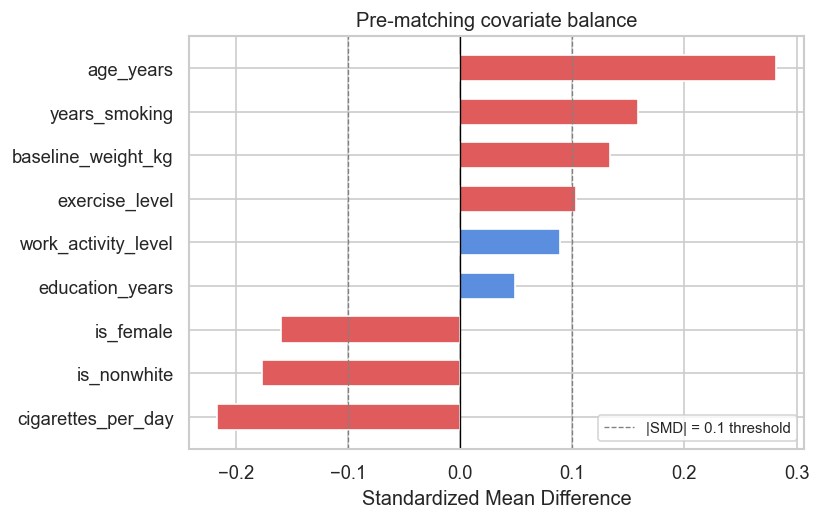

In [140]:
# Sort covariates from most negative to most positive SMD for readability
plot_df = balance_pre["smd"].sort_values()

fig, ax = plt.subplots(figsize=(7, 4.5))

# Color bars red if |SMD| > 0.1 (needs fixing), blue if already balanced
colors = ["#e05c5c" if abs(v) > 0.1 else "#5c8ee0" for v in plot_df]
ax.barh(plot_df.index, plot_df.values, color=colors, height=0.6)

# Reference lines: zero = perfect balance, ±0.1 = acceptable threshold
ax.axvline(0,    color="black", linewidth=0.8)
ax.axvline(0.1,  color="grey",  linewidth=0.8, linestyle="--", label="|SMD| = 0.1 threshold")
ax.axvline(-0.1, color="grey",  linewidth=0.8, linestyle="--")

ax.set_xlabel("Standardized Mean Difference")
ax.set_title("Pre-matching covariate balance")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### Covariate distributions by treatment group

SMDs summarise imbalance in a single number per variable, but two distributions can have the
same mean and still look very different in shape. KDE plots show the full distribution so we
can spot skew, multimodality, or range differences that the SMD alone would miss.

We focus on the five continuous covariates — the binary ones (`is_female`, `is_nonwhite`) are
more naturally summarised by their means.

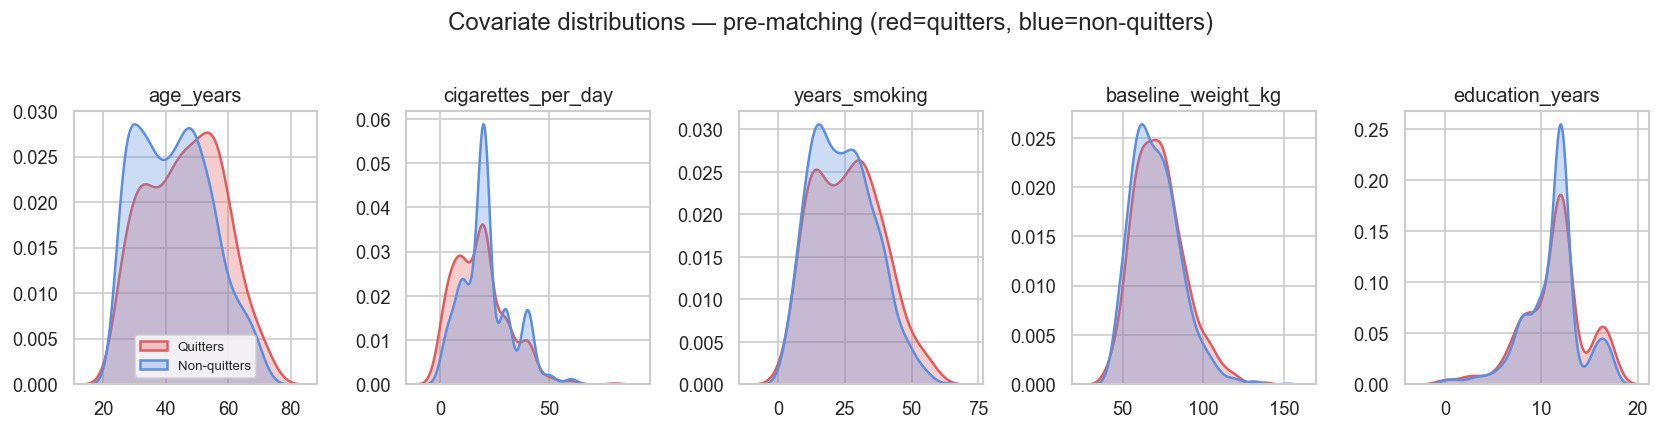

In [141]:
continuous = ["age_years", "cigarettes_per_day", "years_smoking", "baseline_weight_kg", "education_years"]

fig, axes = plt.subplots(1, len(continuous), figsize=(14, 3.5), sharey=False)

for ax, col in zip(axes, continuous):
    for val, label, color in [(1, "Quitters", "#e05c5c"), (0, "Non-quitters", "#5c8ee0")]:
        sns.kdeplot(
            df[df[TREATMENT] == val][col],
            ax=ax, label=label, color=color, fill=True, alpha=0.3, linewidth=1.5
        )
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("")

axes[0].legend(fontsize=8)
fig.suptitle("Covariate distributions — pre-matching (red=quitters, blue=non-quitters)", y=1.02)
plt.tight_layout()
plt.show()

---

## Propensity score estimation

The **propensity score** is the probability that a unit received the treatment, given their
observed covariates:

```
e(X) = P(quit_smoking = 1 | X)
```

This is estimated using logistic regression — we model treatment assignment as a function of
pre-treatment covariates. The key insight (Rosenbaum & Rubin, 1983) is that if we condition
on the propensity score rather than all covariates individually, units with the same score
are balanced on all observed confounders in expectation. This collapses the high-dimensional
matching problem into a one-dimensional one.

**Why statsmodels over sklearn?**

We use `statsmodels` here rather than `sklearn` because we want to inspect the coefficients,
standard errors, and p-values as we build the model incrementally. This builds intuition for
what each variable contributes to treatment assignment. Once the model is finalised, the
predicted probabilities (propensity scores) are all that matters downstream — the coefficients
become irrelevant.

### Feature engineering — polynomial and interaction terms

A flat logistic regression on raw covariates assumes every relationship with quit probability
is perfectly linear. That's unlikely. We follow Hernán & Robins and add:

- **Squared terms** for each continuous covariate — lets the model fit curves (e.g., the
  effect of age on quitting likely accelerates rather than being strictly linear)
- **`cigarettes_per_day × years_smoking` interaction** — captures the joint effect of smoking
  heavily *and* for a long time; someone who smoked 30/day for 30 years is qualitatively
  different from someone who smoked 30/day for 2 years

**Rule for polynomial terms:** always keep the linear term when including a squared term.
Dropping the linear term forces the curve to be symmetric around zero, which is an artificial
constraint with no statistical justification.

In [142]:
# Create squared terms for each continuous covariate as explicit columns.
# We do this rather than writing e.g. I(age_years**2) in the formula string because:
# (1) it's easier to read and debug
# (2) the columns will already exist when we switch to sklearn later
df["age_years_sq"]          = df["age_years"] ** 2
df["cigarettes_per_day_sq"] = df["cigarettes_per_day"] ** 2
df["years_smoking_sq"]      = df["years_smoking"] ** 2
df["baseline_weight_kg_sq"] = df["baseline_weight_kg"] ** 2

# Interaction term: joint effect of smoking intensity × duration.
# Neither variable alone can capture the compounded addiction of heavy long-term smoking.
df["cigarettes_x_years_smoking"] = df["cigarettes_per_day"] * df["years_smoking"]

### Fit the logistic regression

The formula string uses R-style notation: `outcome ~ predictor1 + predictor2 + ...`
Statsmodels handles the intercept automatically.

Key things to look for in the summary:
- **Sign of each coefficient** — does the direction make intuitive sense?
- **Statistical significance** — p-value < 0.05 means we can distinguish the effect from noise
- **Pseudo R-squared** — how much variation in treatment assignment the model explains.
  Don't expect high values here; human behaviour is noisy. What matters is post-matching balance,
  not model fit.

In [143]:
# Full Hernán & Robins propensity score specification:
# 9 base covariates + 4 squared continuous terms + 1 interaction term = 14 predictors
formula = (
    "quit_smoking ~ "
    "age_years + cigarettes_per_day + years_smoking + "       # core smoking/age variables
    "is_female + is_nonwhite + "                              # demographic controls
    "education_years + baseline_weight_kg + "                 # socioeconomic and physical baseline
    "exercise_level + work_activity_level + "                 # lifestyle controls
    "age_years_sq + cigarettes_per_day_sq + "                 # curvature in age and smoking intensity
    "years_smoking_sq + baseline_weight_kg_sq + "             # curvature in duration and weight
    "cigarettes_x_years_smoking"                              # joint intensity × duration effect
)

ps_model = smf.logit(formula, data=df).fit()
ps_model.summary()

Optimization terminated successfully.
         Current function value: 0.536436
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:           quit_smoking   No. Observations:                 1566
Model:                          Logit   Df Residuals:                     1551
Method:                           MLE   Df Model:                           14
Date:                Mon, 29 Jun 2026   Pseudo R-squ.:                 0.05931
Time:                        09:47:12   Log-Likelihood:                -840.06
converged:                       True   LL-Null:                       -893.03
Covariance Type:            nonrobust   LLR p-value:                 3.420e-16
==============================================================================================
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept                     -2.1128      1.422     -1.485      0.137      -4.901       0.675
age_years                      0.1164      0.052      2.254      0.024       0.015       0.218
cigarettes_per_day            -0.0896      0.018     -4.893      0.000      -0.125      -0.054
years_smoking                 -0.0803      0.028     -2.882      0.004      -0.135      -0.026
is_female                     -0.5591      0.152     -3.689      0.000      -0.856      -0.262
is_nonwhite                   -0.8393      0.209     -4.011      0.000      -1.250      -0.429
education_years                0.0360      0.021      1.737      0.082      -0.005       0.077
baseline_weight_kg            -0.0162      0.026     -0.620      0.535      -0.068       0.035
exercise_level                 0.1599      0.088      1.808      0.071      -0.013       0.333
work_activity_level            0.0974      0.096      1.018      0.309      -0.090       0.285
age_years_sq                  -0.0008      0.001     -1.429      0.153      -0.002       0.000
cigarettes_per_day_sq          0.0010      0.000      3.467      0.001       0.000       0.002
years_smoking_sq               0.0008      0.000      1.696      0.090      -0.000       0.002
baseline_weight_kg_sq          0.0001      0.000      0.875      0.382      -0.000       0.000
cigarettes_x_years_smoking     0.0005      0.000      1.167      0.243      -0.000       0.001
==============================================================================================
"""

In [144]:
# Extract predicted probabilities from the fitted model and store on the dataframe.
# model.predict() with no arguments uses the same data the model was fitted on.
# The output is each person's estimated probability of having quit smoking,
# given their observed covariates — this is their propensity score.
df["propensity_score"] = ps_model.predict()

# Summarise the score distribution separately for each group.
# We want to see: (1) do the means differ? (2) how wide is each distribution?
# A well-fitted model should assign higher scores to quitters on average.
df.groupby("quit_smoking")["propensity_score"].describe()

,count,mean,std,min,25%,50%,75%,max
quit_smoking,,,,,,,,
0,1163.0,0.239906,0.104108,0.043644,0.163634,0.226609,0.298529,0.666745
1,403.0,0.307666,0.127111,0.053786,0.220039,0.284259,0.372551,0.781448


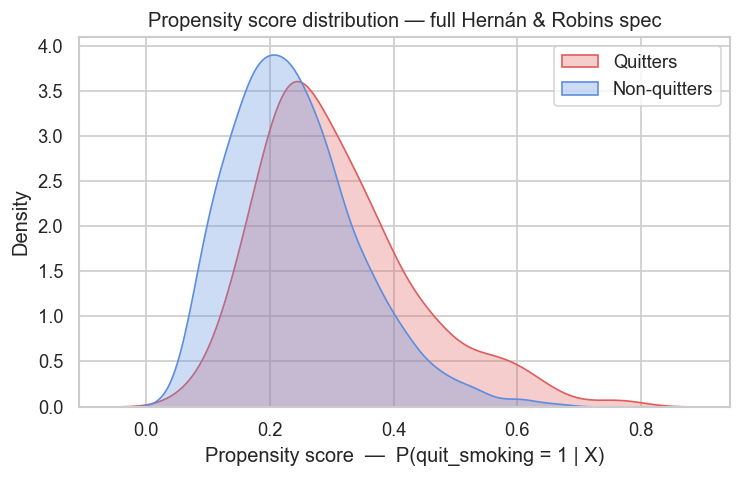

In [145]:
fig, ax = plt.subplots(figsize=(7, 4))

# Overlay KDE distributions for each group
# What we want to see: two overlapping but distinct humps — enough separation for scores
# to be doing useful work, enough overlap for valid matches to exist
for val, label, color in [(1, "Quitters", "#e05c5c"), (0, "Non-quitters", "#5c8ee0")]:
    sns.kdeplot(df[df["quit_smoking"] == val]["propensity_score"],
                ax=ax, label=label, color=color, fill=True, alpha=0.3)

ax.set_xlabel("Propensity score  —  P(quit_smoking = 1 | X)")
ax.set_title("Propensity score distribution — full Hernán & Robins spec")
ax.legend()
plt.show()

In [146]:
ps_treated = df[df["quit_smoking"] == 1]["propensity_score"]
ps_control = df[df["quit_smoking"] == 0]["propensity_score"]

# Common support = the intersection of both score ranges
# overlap_min: the highest minimum (below this, only controls exist)
# overlap_max: the lowest maximum (above this, only treated units exist)
overlap_min = max(ps_treated.min(), ps_control.min())
overlap_max = min(ps_treated.max(), ps_control.max())

print(f"Common support region: [{overlap_min:.3f}, {overlap_max:.3f}]")
print(f"Treated units outside common support: {(ps_treated > overlap_max).sum()} of {len(ps_treated)}")
print(f"\nThese units will be excluded from matching — no comparable control exists for them.")

Common support region: [0.054, 0.667]
Treated units outside common support: 4 of 403

These units will be excluded from matching — no comparable control exists for them.


### Common support check

**Common support** (also called overlap) is the range of propensity scores where both treated
and control units exist. Matching can only happen within this region — a quitter with a score
of 0.8 cannot be matched if no non-quitter has a score anywhere near 0.8.

We compute the overlap region as:
- `overlap_min` = the higher of the two group minimums
- `overlap_max` = the lower of the two group maximums

Any treated unit outside this range has no valid match and should be excluded from the analysis.
Keeping them in and forcing a match would pair them with controls that look nothing like them,
defeating the purpose of matching entirely.

In [147]:
# Caliper = 0.2 × SD of the propensity score (Austin, 2011)
# This is computed on the full sample before trimming to common support
caliper = 0.2 * df["propensity_score"].std()

print(f"Propensity score SD : {df['propensity_score'].std():.4f}")
print(f"Caliper (0.2 × SD) : {caliper:.4f}")
print(f"\nScore range         : [{df['propensity_score'].min():.3f}, {df['propensity_score'].max():.3f}]")
print(f"Caliper as % of range: {caliper / (df['propensity_score'].max() - df['propensity_score'].min()) * 100:.1f}%")
print(f"\nA caliper of {caliper:.4f} means two units must be within ~{caliper:.3f} propensity score")
print(f"points of each other to be considered a valid match.")

Propensity score SD : 0.1143
Caliper (0.2 × SD) : 0.0229

Score range         : [0.044, 0.781]
Caliper as % of range: 3.1%

A caliper of 0.0229 means two units must be within ~0.023 propensity score
points of each other to be considered a valid match.


### Caliper — setting a maximum match distance

Even within the common support region, some nearest-neighbour matches may still be poor — the
closest available control might still be far away in propensity score terms. A **caliper** sets
a maximum allowable distance. Any treated unit whose closest control exceeds the caliper gets
dropped rather than badly matched.

The convention is to set the caliper at **0.2 standard deviations** of the propensity score
distribution. This is the Austin (2011) recommendation and is the most widely used default.

In [148]:
from sklearn.neighbors import NearestNeighbors

# Separate the two pools we are matching from.
# .copy() ensures modifications (like removing matched controls) don't affect df.
treated = df[df["quit_smoking"] == 1].copy()  # the 403 quitters — each needs one match
control = df[df["quit_smoking"] == 0].copy()  # the 1163 non-quitters — the matching pool

print(f"Treated pool (quitters)    : {len(treated)}")
print(f"Control pool (non-quitters): {len(control)}")
print(f"\nFor every quitter we will find their nearest neighbour in the control pool.")
print(f"If the distance exceeds the caliper ({caliper:.4f}), the quitter is dropped.")

Treated pool (quitters)    : 403
Control pool (non-quitters): 1163

For every quitter we will find their nearest neighbour in the control pool.
If the distance exceeds the caliper (0.0229), the quitter is dropped.


---

## Matching

We now perform **1-to-1 nearest-neighbour matching without replacement** on the propensity score.

**What this means:**
- For each quitter, find the one non-quitter whose propensity score is closest to theirs
- Once a non-quitter is matched, they are removed from the pool — they cannot be matched again
- If the closest available non-quitter is further than the caliper, the quitter is dropped

**Why without replacement?**
Matching without replacement produces a cleaner dataset where each observation appears once.
The cost is that later quitters (in random processing order) may get slightly worse matches
because the best controls have already been taken. With replacement gives better individual
matches but complicates variance estimation downstream.

We use sklearn's `NearestNeighbors` as the distance calculator — it's not a predictive model,
just an efficient index for finding closest points in a 1-dimensional space (the propensity score).

In [149]:
# Build a nearest-neighbour index on the control pool's propensity scores.
# NearestNeighbors is not a predictive model — it's purely a distance calculator.
# n_neighbors=1 means we want exactly one match per treated unit (1-to-1 matching).
# Double brackets give a 2D DataFrame (1163, 1) — sklearn requires 2D array input,
# not a 1D Series which single brackets would produce.
nn = NearestNeighbors(n_neighbors=1, metric="euclidean")
nn.fit(control[["propensity_score"]])

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",1
,"radius radius: float, default=1.0Range of parameter space to use by default for :meth:`radius_neighbors`queries.",1.0
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'euclidean'
,"p p: float (positive), default=2Parameter for the Minkowski metric fromsklearn.metrics.pairwise.pairwise_distances. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [150]:
distances, indices = nn.kneighbors(treated[["propensity_score"]])

In [151]:
print(distances[:5])
print(indices[:5])

[[1.99163147e-04]
 [1.83595160e-05]
 [5.24714913e-04]
 [2.09037084e-04]
 [1.83161843e-05]]
[[ 732]
 [1006]
 [  34]
 [ 732]
 [ 560]]


In [158]:
import random
random.seed(42)

treated_shuffled = treated.sample(frac=1, random_state=42)
available_control = control.copy()

matched_treated = []
matched_control = []
unmatched = 0

for _, t_row in treated_shuffled.iterrows():
    if available_control.empty:
        unmatched += 1
        continue

    # Rebuild index on remaining available controls
    nn_iter = NearestNeighbors(n_neighbors=1, metric="euclidean")
    nn_iter.fit(available_control[["propensity_score"]])

    dist, idx = nn_iter.kneighbors(pd.DataFrame({"propensity_score": [t_row["propensity_score"]]}))
    dist = dist[0][0]
    idx  = idx[0][0]

    if dist > caliper:
        unmatched += 1
        continue

    matched_row = available_control.iloc[idx]
    matched_treated.append(t_row)
    matched_control.append(matched_row)

    # Remove the matched control so it can't be reused
    available_control = available_control.drop(matched_row.name)

print(f"Matched pairs             : {len(matched_treated)}")
print(f"Dropped (caliper/no match): {unmatched}")

control_ids = [r.name for r in matched_control]
print(f"Unique controls used      : {len(set(control_ids))}")
print(f"Duplicates                : {len(control_ids) - len(set(control_ids))}")

Matched pairs             : 389
Dropped (caliper/no match): 14
Unique controls used      : 389
Duplicates                : 0


In [154]:
control_ids = [r.name for r in matched_control]
print(f"Total matches       : {len(control_ids)}")
print(f"Unique controls used: {len(set(control_ids))}")
print(f"Duplicates          : {len(control_ids) - len(set(control_ids))}")


Total matches       : 400
Unique controls used: 298
Duplicates          : 102


In [159]:
df_matched = pd.concat([
    pd.DataFrame(matched_treated),
    pd.DataFrame(matched_control)
], ignore_index=True)

print(f"Matched dataset shape: {df_matched.shape}")
print(f"Treated: {df_matched[TREATMENT].sum()}")
print(f"Control: {(df_matched[TREATMENT] == 0).sum()}")

Matched dataset shape: (778, 73)
Treated: 389.0
Control: 389


In [161]:
balance_post = smd(df_matched, COVARIATES, TREATMENT)

In [162]:
comparison = pd.DataFrame({
    "pre_match":  balance_pre["smd"],
    "post_match": balance_post["smd"],
}).sort_values("pre_match", ascending=False)

In [163]:
comparison

,pre_match,post_match
covariate,,
age_years,0.281981,-0.002325
years_smoking,0.158918,-0.006731
baseline_weight_kg,0.133216,0.025553
exercise_level,0.103586,0.017819
work_activity_level,0.088714,0.019456
education_years,0.049053,-0.014687
is_female,-0.160129,0.041365
is_nonwhite,-0.176918,-0.059526
cigarettes_per_day,-0.216675,-0.020426


In [164]:
matched_treated_outcome = df_matched[df_matched[TREATMENT] == 1][OUTCOME]
matched_control_outcome  = df_matched[df_matched[TREATMENT] == 0][OUTCOME]

att_matched = matched_treated_outcome.mean() - matched_control_outcome.mean()

print(f"Naive ATT (unadjusted) : {naive_att:.2f} kg")
print(f"PSM ATT (matched)      : {att_matched:.2f} kg")
print(f"Hernán & Robins target : ~3.44 kg")

Naive ATT (unadjusted) : 2.54 kg
PSM ATT (matched)      : 3.55 kg
Hernán & Robins target : ~3.44 kg


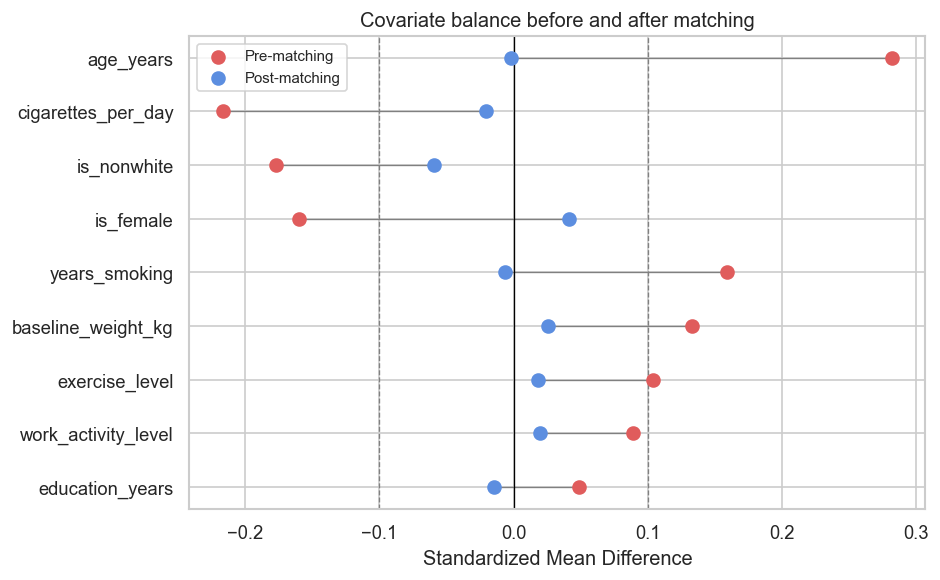

In [165]:
fig, ax = plt.subplots(figsize=(8, 5))

y_pos = range(len(COVARIATES))
covs  = balance_pre["smd"].sort_values(key=abs, ascending=True).index

pre  = balance_pre.loc[covs, "smd"]
post = balance_post.loc[covs, "smd"]

ax.scatter(pre,  y_pos, color="#e05c5c", zorder=3, s=60, label="Pre-matching")
ax.scatter(post, y_pos, color="#5c8ee0", zorder=3, s=60, label="Post-matching")

for i, cov in enumerate(covs):
    ax.plot([pre[cov], post[cov]], [i, i], color="grey", linewidth=0.8, zorder=2)

ax.axvline(0,    color="black", linewidth=0.8)
ax.axvline(0.1,  color="grey",  linewidth=0.8, linestyle="--")
ax.axvline(-0.1, color="grey",  linewidth=0.8, linestyle="--")

ax.set_yticks(y_pos)
ax.set_yticklabels(covs)
ax.set_xlabel("Standardized Mean Difference")
ax.set_title("Covariate balance before and after matching")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

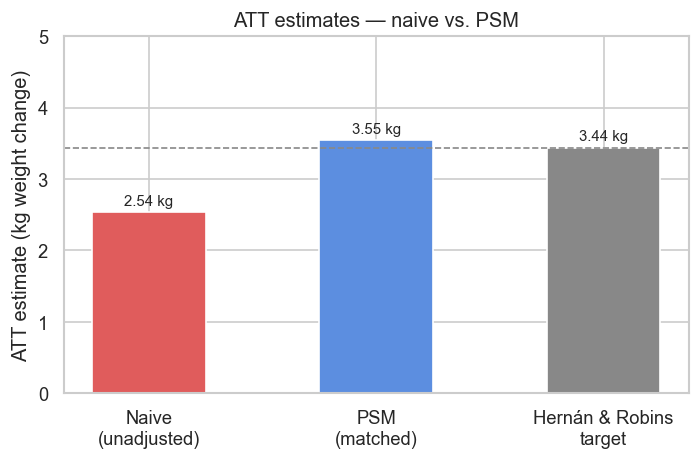

In [166]:
fig, ax = plt.subplots(figsize=(6, 4))

estimates = {
    "Naive\n(unadjusted)": naive_att,
    "PSM\n(matched)":      att_matched,
    "Hernán & Robins\ntarget":          3.44,
}

colors = ["#e05c5c", "#5c8ee0", "#888888"]
bars = ax.bar(estimates.keys(), estimates.values(), color=colors, width=0.5)

ax.axhline(3.44, color="#888888", linewidth=1, linestyle="--")
ax.set_ylabel("ATT estimate (kg weight change)")
ax.set_title("ATT estimates — naive vs. PSM")
ax.set_ylim(0, 5)

for bar, val in zip(bars, estimates.values()):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.1,
            f"{val:.2f} kg", ha="center", fontsize=9)

plt.tight_layout()
plt.show()


In [167]:
from scipy import stats

paired_diff = (
    df_matched[df_matched[TREATMENT] == 1][OUTCOME].values -
    df_matched[df_matched[TREATMENT] == 0][OUTCOME].values
)

t_stat, p_value = stats.ttest_1samp(paired_diff, popmean=0)

ci_low  = paired_diff.mean() - 1.96 * paired_diff.std() / np.sqrt(len(paired_diff))
ci_high = paired_diff.mean() + 1.96 * paired_diff.std() / np.sqrt(len(paired_diff))

print(f"ATT estimate : {paired_diff.mean():.3f} kg")
print(f"95% CI       : [{ci_low:.3f}, {ci_high:.3f}]")
print(f"t-statistic  : {t_stat:.3f}")
print(f"p-value      : {p_value:.4f}")



ATT estimate : 3.546 kg
95% CI       : [2.440, 4.651]
t-statistic  : 6.277
p-value      : 0.0000


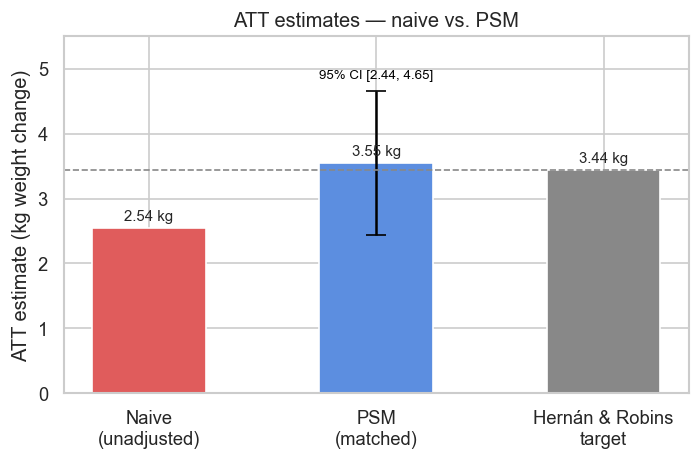

In [168]:
fig, ax = plt.subplots(figsize=(6, 4))

estimates = {
    "Naive\n(unadjusted)": naive_att,
    "PSM\n(matched)":      att_matched,
    "Hernán & Robins\ntarget": 3.44,
}

colors = ["#e05c5c", "#5c8ee0", "#888888"]
bars = ax.bar(estimates.keys(), estimates.values(), color=colors, width=0.5)

ax.errorbar(
    x=1, y=att_matched,
    yerr=[[att_matched - ci_low], [ci_high - att_matched]],
    fmt="none", color="black", capsize=6, linewidth=1.5
)

ax.axhline(3.44, color="#888888", linewidth=1, linestyle="--")
ax.set_ylabel("ATT estimate (kg weight change)")
ax.set_title("ATT estimates — naive vs. PSM")
ax.set_ylim(0, 5.5)

for bar, val in zip(bars, estimates.values()):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.12,
            f"{val:.2f} kg", ha="center", fontsize=9)

ax.text(1, ci_high + 0.2, f"95% CI [{ci_low:.2f}, {ci_high:.2f}]",
        ha="center", fontsize=8, color="black")

plt.tight_layout()
plt.show()